# GPR w/ Priors
- This takes the priors we defined in the priors5_prior_generating_func notebook and that we wrote in the helpers.priors moduls and uses them as the priors to fit Gaussian spectrum kernels.
- Fit combinations of the priors and compare models using validation set performance with an Occam penalty.

In [23]:
# Importing and data hopo hopo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from astropy.time import Time
from astropy.timeseries import LombScargle

from scipy.signal import find_peaks
from scipy.optimize import curve_fit, minimize

import celerite2
from celerite2 import terms

from prettytable import PrettyTable

import sys
from pathlib import Path

sys.path.append(str(Path('../..').resolve()))

from helpers.LSP_peaks import fit_peaks, set_period_axes
from helpers.df_ops import prepare_df, split_df
from helpers.priors import find_classify_signals, get_priors


# Individual stars
raw_HD81809 = pd.read_csv(r"../../Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
raw_HD160346 = pd.read_csv(r"../../Data/benchmark/HD160346_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
raw_HD201091 =pd.read_csv(r"../../Data/benchmark/HD201091_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)

data_HD81809 = prepare_df(raw_HD81809)
data_HD160346 = prepare_df(raw_HD160346)
data_HD201091 = prepare_df(raw_HD201091)

train_HD81809,  valid_HD81809,  test_HD81809  = split_df(data_HD81809)
train_HD160346, valid_HD160346, test_HD160346 = split_df(data_HD160346)
train_HD201091, valid_HD201091, test_HD201091 = split_df(data_HD201091)


C:\Users\Joey\AppData\Local\Temp\ipykernel_15684\2370008255.py:29: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  raw_HD81809 = pd.read_csv(r"../../Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
C:\Users\Joey\AppData\Local\Temp\ipykernel_15684\2370008255.py:30: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  raw_HD160346 = pd.read_csv(r"../../Data/benchmark/HD160346_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
C:\Users\Joey\AppData\Local\Temp\ipykernel_15684\2370008255.py:31: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support rege

- Try doing the GPR on HD81809

C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


In iteration 0, period at 2991.66 days was accepted.
In iteration 1, period at 40.25 days was accepted.
In iteration 2, period at 44.27 days was accepted.
In iteration 3, period at 1813.07 days was accepted.
Peak at period 41.71 days was identified to be an alias of 40.25 days at mult 1.00 by tolerance 0.04.
Peak at period 7119.84 days was identified to be an alias of 1813.07 days at mult 4.00 by tolerance 0.02.
In iteration 4, period at 37.33 days was accepted.
In iteration 5, period at 6847.55 days was accepted.
Peak at period 42.44 days was identified to be an alias of 44.27 days at mult 1.00 by tolerance 0.04.
Peak at period 21.27 days was identified to be an alias of 44.27 days at mult 0.50 by tolerance 0.04.
Peak at period 38.06 days was identified to be an alias of 37.33 days at mult 1.00 by tolerance 0.02.
Period of 47.19 days has SNR of 4.633401992630882 < 5.
Iteration 6 did not find a frequency: terminating loop.


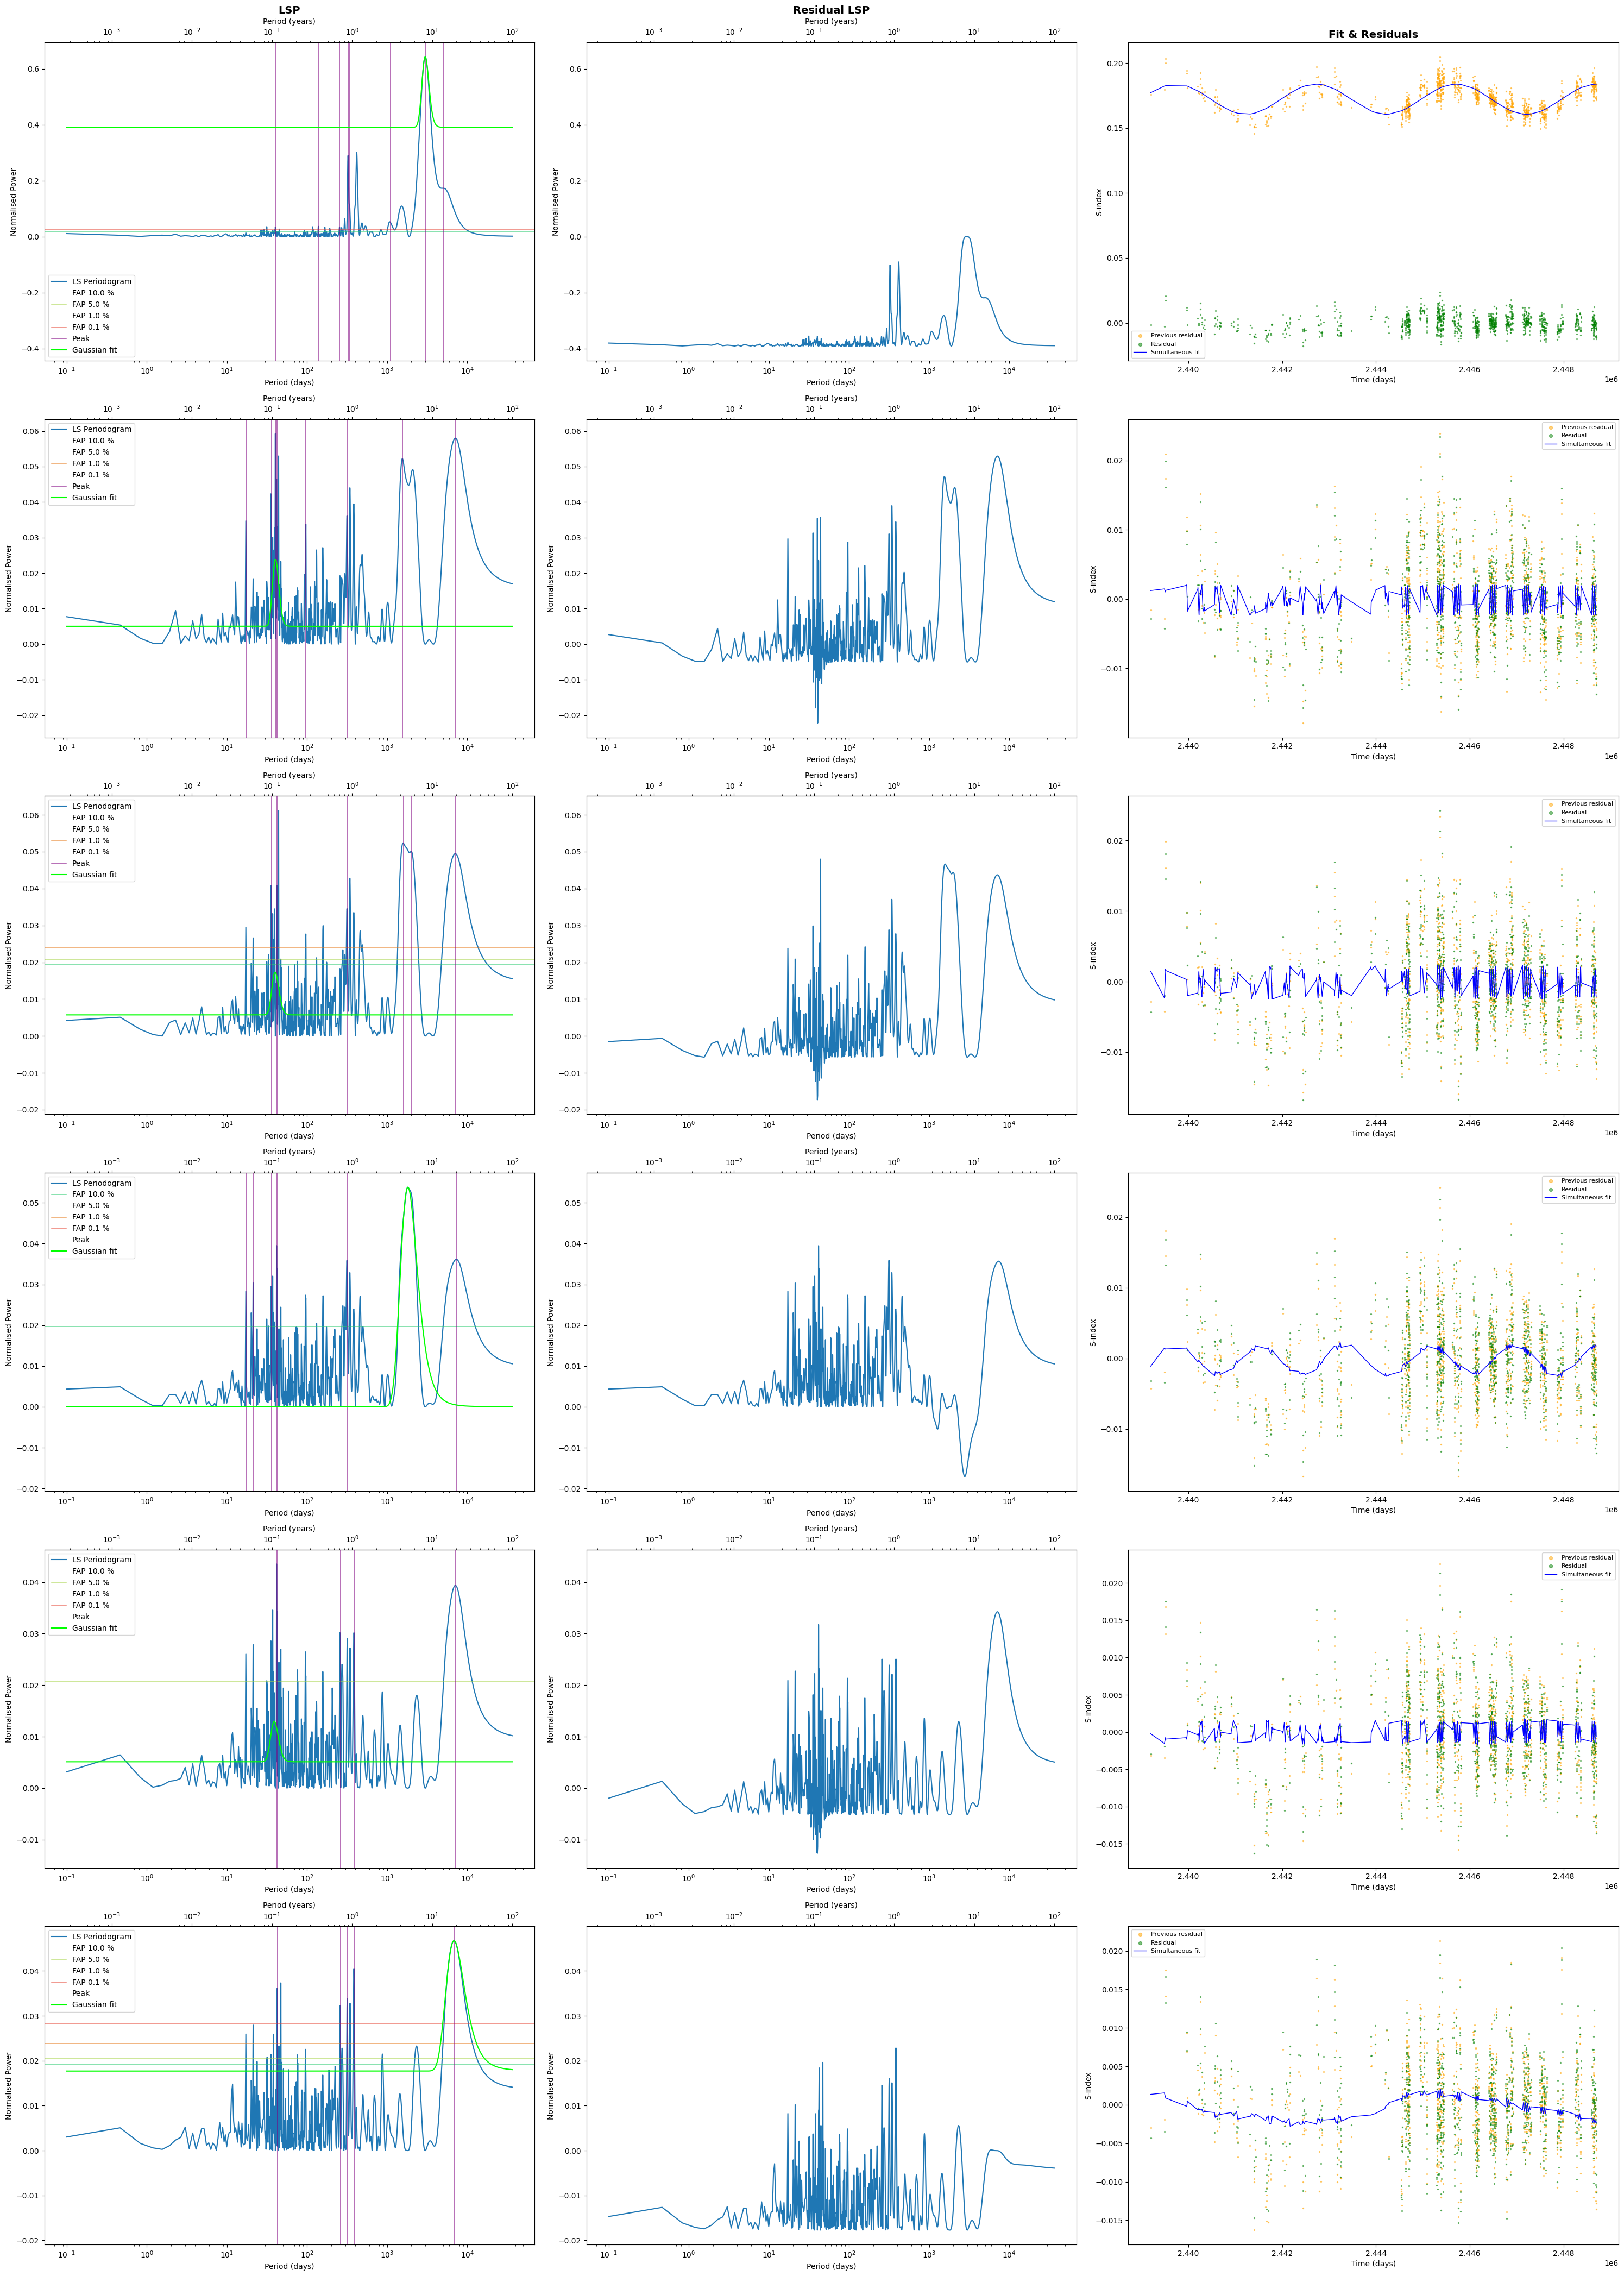

Accepted periods and their heights
+---------+-------+--------+------------+
|   Days  | Years | Height |    SNR     |
+---------+-------+--------+------------+
| 2991.66 |  8.20 | 0.6430 |  76181.21  |
|  40.25  |  0.11 | 0.0593 |    8.76    |
|  44.27  |  0.12 | 0.0612 |    8.00    |
| 1813.07 |  4.97 | 0.0538 |  3539.12   |
|  37.33  |  0.10 | 0.0346 |    5.32    |
| 6847.55 | 18.76 | 0.0467 | 3575428.99 |
+---------+-------+--------+------------+


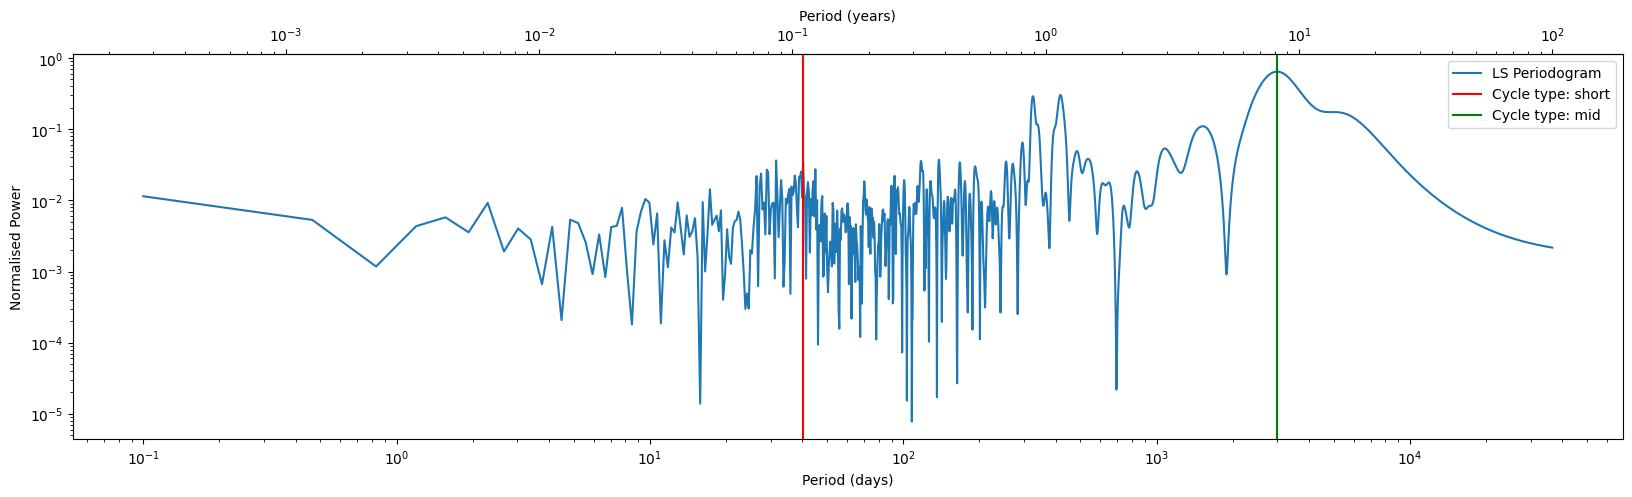

Classified Signals
+------------+------------+-------------+
| Cycle Type | Prior Days | Prior Years |
+------------+------------+-------------+
|   Short    |   40.25    |     0.11    |
|    Mid     |  2991.66   |     8.20    |
+------------+------------+-------------+
+------------+------------+-------------+--------+
| Cycle Type | Prior Days | Prior Years | Source |
+------------+------------+-------------+--------+
|   Short    |   40.25    |     0.11    | found  |
|    Mid     |  2991.66   |     8.20    | found  |
|    Long    |  36500.00  |    100.00   |  mean  |
+------------+------------+-------------+--------+


In [24]:
classified_signal_data = find_classify_signals(train_HD81809)
priors = get_priors(classified_signal_data, 'G') 

In [25]:
def set_params(log_params, k, gp):
    # k = len(log_params) // 3
    params = np.exp(log_params)
    sigmas = params[0:k]
    rhos = params[k:2*k]
    qs = params[2*k::]
    
    gp.kernel = terms.SHOTerm(sigma=sigmas[0], rho=rhos[0], Q=qs[0])
    for k_idx in range(1,k):
        gp.kernel += terms.SHOTerm(sigma=sigmas[k_idx], rho=rhos[k_idx], Q=qs[k_idx])
    return gp

def NLL(log_params, gp, k, y):
    '''
    Calculates the NLL of a set of parameters for a local gp
    '''
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)

True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
For k = 3
+--------+-------+------------+-------------+
| sigma  |   Q   | rho (days) | rho (years) |
+--------+-------+------------+-------------+
| 0.0027 | 10.00 |   39.39    |     0.11    |
| 0.0090 | 10.00 |  2985.08   |     8.18    |
| 0.0010 |  0.50 |  54750.00  |    150.00   |
+--------+-------+------------+-------------+


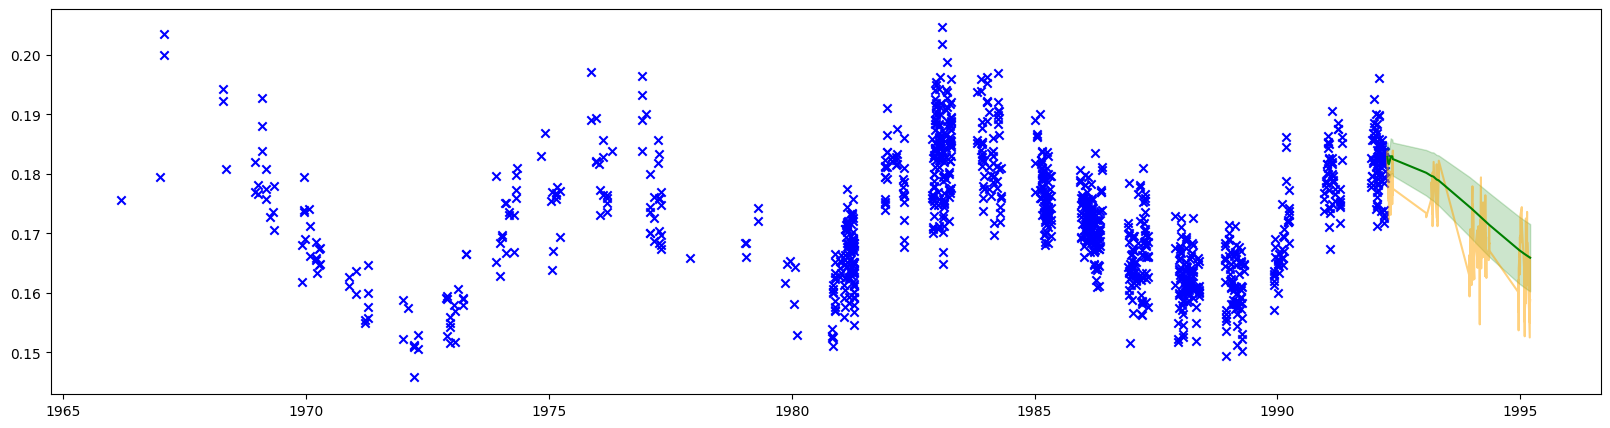

In [26]:
train_df = train_HD81809
k = 3
error_percent = 5
train_yerr = train_df['sind'] * error_percent / 100
verbose = True

# Some key stats
mean_train = train_df['sind'].mean()
std_train = train_df['sind'].std()

# Set up initial guesses
sigma_0s = [std_train/k for _ in range(k)] # Split the amplitudes evenly
rho_0s = [priors['short'], priors['mid'], priors['long']] # The periods: use the hard-earned priors
q_0s = [np.random.uniform(0.5,1) for _ in range(k)] # Randomise them in the underdamped regime

# The optimiser works in log space so initial guesses must be log
initial_guess = np.concatenate([np.log(sigma_0s),
                                                np.log(rho_0s),
                                                np.log(q_0s)])

# Create the optimisation bounds
sigma_upper = 5 * std_train # this is a bit high but can be tweaked downwards
sigma_bounds = [(np.log(1e-4), np.log(sigma_upper)) for _ in range(k)]
rho_bounds = [(np.log(0.1), np.log(200)), (np.log(200), np.log(20*365)), (np.log(20*365), np.log(150*365))]# Force them to live in the correct regimes
q_bounds = [(np.log(0.5),np.log(10)) for _ in range(k)]
bounds = np.concatenate([sigma_bounds,
                                                rho_bounds,
                                                q_bounds])

# Create the initial kernel
kernel = terms.SHOTerm(sigma = sigma_0s[0],
                                        rho = rho_0s[0],
                                        Q = q_0s[0])
for k_idx in range(1,k):
    kernel += terms.SHOTerm(sigma = sigma_0s[k_idx],
                                        rho = rho_0s[k_idx],
                                        Q = q_0s[k_idx])
    
# Define the GP
gp = celerite2.GaussianProcess(kernel, mean = mean_train)
gp.compute(train_df['day'], yerr = train_yerr)

# Train the GP
gp_results = minimize(NLL, initial_guess,
                    args = (gp, k, train_df['sind'].to_numpy()),
                    method = 'L-BFGS-B',
                    bounds = bounds)
gp = set_params(gp_results.x, k, gp)
gp.recompute()
best = np.exp(gp_results.x)

# Print the best optimisation results
if verbose:
    table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
    best_sigmas = best[0:k]
    best_rhos = best[k:2*k]
    best_qs = best[2*k:]

    for k_idx in range(k):
        table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",  f"{best_rhos[k_idx]:.2f}",  f"{best_rhos[k_idx]/365:.2f}"])
    print(gp_results.success, gp_results.message)
    print(f"For k = {k}")
    print(table)

#---------Predict it forwards
valid_df = valid_HD81809
plot = True
ax = None

t_pred = valid_df['day']  # must match units used in gp.compute
mu, cov = gp.predict(train_df['sind'], t = t_pred, return_var = True) 
sigma = np.sqrt(cov)

if plot:
    results = pd.DataFrame({
    'forecast' : mu,
    'lower'    : mu - sigma,
    'upper'    : mu + sigma,
    }, index=valid_df.index)

    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 5))
    ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker = 'x')
    ax.plot(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha = 0.5)

    ax.plot(valid_df['year'], results['forecast'], color='green', label='Predictions')
    ax.fill_between(valid_df['year'], results['lower'], results['upper'], color='green', alpha=0.2, label='Uncertainties')


- Write it into a func

In [27]:
def fit_compare_models(train_df, priors):
    '''
    Priors will be a dictionary of short, mid, and long priors.
    This function will fit GPR models with spectrum kernels to the train_df based on the priors.
    It will compare different complexities of spectrum kernels k = 1, 2, 3.
    It will compare different combinations of the priors based on valid performance and Occam penalty.
    It will plot them against each other and output the best parameters. 
    '''
    train_mean = train_df["sind"].mean()
    train_std  = train_df["sind"].std()

    
    

- Testing


In [ ]:
classified_signal_data = find_classify_signals(train_HD81809)
priors = get_priors(classified_signal_data, 'G') 

In iteration 0, period at 2991.66 days was accepted.
